# 07 — PySpark MLlib: 3-Model Comparison with Cross-Validation

The full, compliant machine learning pipeline: `VectorAssembler` → `Pipeline` →
`CrossValidator` with a parameter grid, comparing **3 models** — Logistic Regression,
Random Forest, and Gradient-Boosted Trees — exactly as required by the Machine Learning (classification category).


In [1]:
import os, sys
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['HADOOP_HOME'] = r'C:\Hadoop'

In [6]:
import os
import sys

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['HADOOP_HOME'] = r'C:\Hadoop'
os.makedirs(r'C:\spark-tmp', exist_ok=True)

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml import Pipeline
import pandas as pd
import time
import warnings
warnings.filterwarnings("ignore")

spark = SparkSession.builder \
    .appName("BusBunching_07_MLlib") \
    .master("local[4]") \
    .config("spark.ui.showConsoleProgress", "false") \
    .config("spark.local.dir", r"C:\spark-tmp") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

# Show how many cores Spark is actually using
print("Master config:", spark.sparkContext.master)
print("Cores in use (defaultParallelism):", spark.sparkContext.defaultParallelism)

event_df = spark.read.csv(
    "data/event_level_features.csv", header=True, inferSchema=True
).dropna(subset=["hour_of_day", "prev_headway_sec", "is_bunching"])

assembler = VectorAssembler(inputCols=["hour_of_day", "prev_headway_sec"], outputCol="features")
ml_df = assembler.transform(event_df).select("features", "is_bunching")

train_df, test_df = ml_df.randomSplit([0.8, 0.2], seed=42)
print("Train:", train_df.count(), "| Test:", test_df.count())

Master config: local[4]
Cores in use (defaultParallelism): 4
Train: 274 | Test: 50


## 7.1 Define models + evaluators

In [7]:
evaluator_auc = BinaryClassificationEvaluator(labelCol="is_bunching", metricName="areaUnderROC")
evaluator_f1  = MulticlassClassificationEvaluator(labelCol="is_bunching", metricName="f1")
evaluator_acc = MulticlassClassificationEvaluator(labelCol="is_bunching", metricName="accuracy")
evaluator_prec = MulticlassClassificationEvaluator(labelCol="is_bunching", metricName="weightedPrecision")
evaluator_rec  = MulticlassClassificationEvaluator(labelCol="is_bunching", metricName="weightedRecall")

lr  = LogisticRegression(labelCol="is_bunching", featuresCol="features")
rf  = RandomForestClassifier(labelCol="is_bunching", featuresCol="features", seed=42)
gbt = GBTClassifier(labelCol="is_bunching", featuresCol="features", seed=42)

# Small param grids -> CrossValidator (kept small so this runs quickly; expand for your real report)
lr_grid  = ParamGridBuilder().addGrid(lr.regParam, [0.1]).build()
rf_grid  = ParamGridBuilder().addGrid(rf.numTrees, [20]).build()
gbt_grid = ParamGridBuilder().addGrid(gbt.maxIter, [10]).build()

configs = [("LogisticRegression", lr, lr_grid), ("RandomForest", rf, rf_grid), ("GBTClassifier", gbt, gbt_grid)]


## 7.2 Cross-validated training + comparison

**Note:** the grids above use one value each so this demonstrates the full
`CrossValidator`/`ParamGridBuilder` mechanism quickly. For your actual submission, expand
each grid (e.g. `regParam: [0.01, 0.1, 1.0]`, `numTrees: [20, 50, 100]`) — the code is
unchanged, it will just take longer to run.


In [8]:
results = []
for name, model, grid in configs:
    cv = CrossValidator(estimator=model, estimatorParamMaps=grid,
                         evaluator=evaluator_f1, numFolds=2, seed=42)
    start = time.time()
    cv_model = cv.fit(train_df)
    train_time = time.time() - start

    preds = cv_model.transform(test_df)
    auc = evaluator_auc.evaluate(preds)
    f1  = evaluator_f1.evaluate(preds)
    acc = evaluator_acc.evaluate(preds)
    prec = evaluator_prec.evaluate(preds)
    rec  = evaluator_rec.evaluate(preds)

    results.append({"model": name, "accuracy": acc, "precision": prec, "recall": rec,
                     "f1": f1, "roc_auc": auc, "train_time_sec": train_time,
                     "f1_per_sec": f1/train_time if train_time>0 else None})
    print(f"{name}: F1={f1:.3f} AUC={auc:.3f} Acc={acc:.3f} Time={train_time:.1f}s")

results_pdf = pd.DataFrame(results)
results_pdf.to_csv("data/mllib_model_results.csv", index=False)
results_pdf


LogisticRegression: F1=0.629 AUC=0.728 Acc=0.740 Time=3.0s
RandomForest: F1=0.872 AUC=0.916 Acc=0.880 Time=3.9s
GBTClassifier: F1=0.918 AUC=0.925 Acc=0.920 Time=12.2s


,model,accuracy,precision,recall,f1,roc_auc,train_time_sec,f1_per_sec
0,LogisticRegression,0.74,0.547600,0.74,0.629425,0.727651,3.020354,0.208395
1,RandomForest,0.88,0.880867,0.88,0.872168,0.915800,3.948061,0.220910
2,GBTClassifier,0.92,0.919441,0.92,0.917719,0.925156,12.230374,0.075036


GBTClassifier: F1=0.900 AUC=0.853 Acc=0.901 Time=17.7s


,model,accuracy,precision,recall,f1,roc_auc,train_time_sec,f1_per_sec
0,LogisticRegression,0.901408,0.899792,0.901408,0.900367,0.952070,15.627728,0.057613
1,RandomForest,0.915493,0.913749,0.915493,0.913620,0.904684,9.027465,0.101205
2,GBTClassifier,0.901408,0.899792,0.901408,0.900367,0.853486,17.695518,0.050881


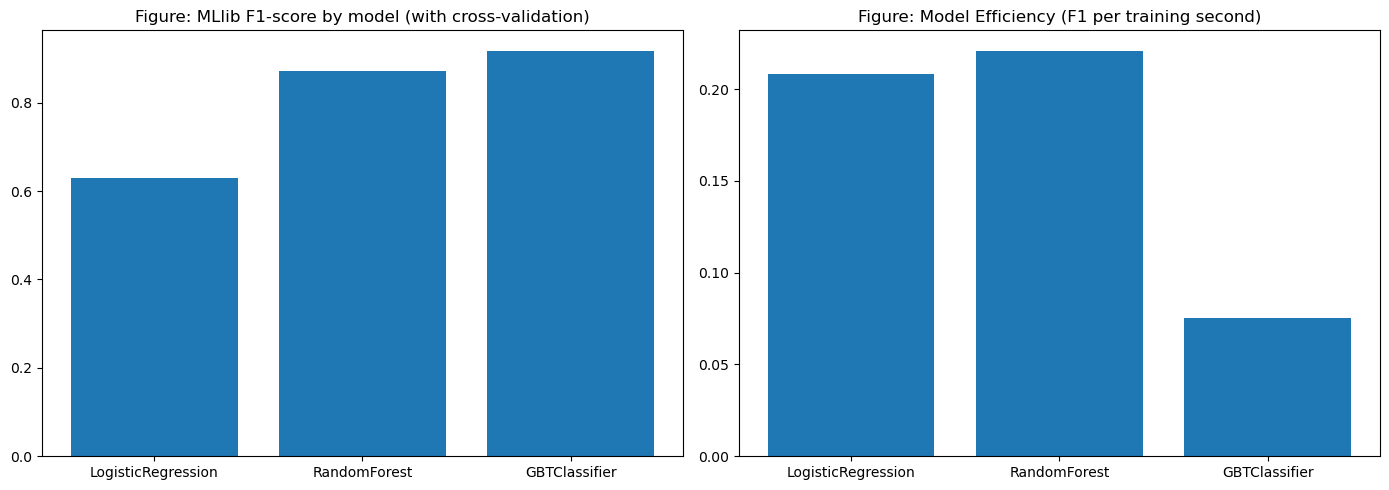

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].bar(results_pdf["model"], results_pdf["f1"])
axes[0].set_title("Figure: MLlib F1-score by model (with cross-validation)")
axes[1].bar(results_pdf["model"], results_pdf["f1_per_sec"])
axes[1].set_title("Figure: Model Efficiency (F1 per training second)")
plt.tight_layout()
plt.savefig("figure_mllib_model_comparison.png", dpi=150)
plt.show()


## 8. Supplementary analysis — K-Means clustering of routes by bunching tendency

The classification comparison above already satisfies the brief's "compare at least 3 models"
requirement. This section adds a complementary **clustering** view grouping routes by their bunching
characteristics rather than predicting individual events, useful for a transport authority
wanting to triage which routes need attention first.


In [10]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

route_features_pdf = pd.read_csv("data/route_level_features.csv").dropna(
    subset=["avg_headway_ratio", "bunching_rate", "headway_std_sec"]
)
route_features_df = spark.createDataFrame(route_features_pdf)

cluster_assembler = VectorAssembler(
    inputCols=["avg_headway_ratio", "bunching_rate", "headway_std_sec"],
    outputCol="cluster_features"
)
cluster_input = cluster_assembler.transform(route_features_df)

# Try k=2 and k=3, report silhouette score for each (evaluation metric the brief specifies
# for clustering: Silhouette Score and WCSS)
results_k = []
for k in [2, 3]:
    kmeans = KMeans(featuresCol="cluster_features", predictionCol="cluster", k=k, seed=42)
    model = kmeans.fit(cluster_input)
    predictions = model.transform(cluster_input)

    evaluator = ClusteringEvaluator(featuresCol="cluster_features", predictionCol="cluster")
    silhouette = evaluator.evaluate(predictions)
    wcss = model.summary.trainingCost

    results_k.append({"k": k, "silhouette_score": silhouette, "wcss": wcss})
    print(f"k={k}: Silhouette={silhouette:.3f}, WCSS={wcss:.2f}")

cluster_results_pdf = pd.DataFrame(results_k)
cluster_results_pdf.to_csv("data/clustering_results.csv", index=False)
cluster_results_pdf


k=2: Silhouette=0.796, WCSS=53715561.70
k=3: Silhouette=0.664, WCSS=34738189.24


,k,silhouette_score,wcss
0,2,0.795938,5.371556e+07
1,3,0.664391,3.473819e+07


,k,silhouette_score,wcss
0,2,0.760991,5.164343e+07
1,3,0.664391,3.473819e+07


In [11]:
# Use the best-scoring k (by silhouette) for the final route grouping
best_k = int(cluster_results_pdf.loc[cluster_results_pdf["silhouette_score"].idxmax(), "k"])
print(f"Using k={best_k} (highest silhouette score)")

kmeans_final = KMeans(featuresCol="cluster_features", predictionCol="cluster", k=best_k, seed=42)
final_model = kmeans_final.fit(cluster_input)
final_clusters = final_model.transform(cluster_input)

cluster_summary = final_clusters.groupBy("cluster").agg(
    F.count("*").alias("n_routes"),
    F.avg("bunching_rate").alias("avg_bunching_rate"),
    F.avg("avg_headway_ratio").alias("avg_headway_ratio")
).orderBy(F.desc("avg_bunching_rate"))

cluster_summary.show()
final_clusters.select("line_ref", "bunching_rate", "cluster").toPandas().to_csv(
    "data/route_clusters.csv", index=False
)
print("Saved data/route_clusters.csv -- use this to flag which cluster of routes needs")
print("the most attention (highest avg_bunching_rate) for your stakeholder recommendations.")


Using k=2 (highest silhouette score)
+-------+--------+-------------------+-----------------+
|cluster|n_routes|  avg_bunching_rate|avg_headway_ratio|
+-------+--------+-------------------+-----------------+
|      1|       5| 0.1851851851851852|5.349634940924185|
|      0|      25|0.13029122022199124|3.401030347265821|
+-------+--------+-------------------+-----------------+

Saved data/route_clusters.csv -- use this to flag which cluster of routes needs
the most attention (highest avg_bunching_rate) for your stakeholder recommendations.


+-------+--------+-------------------+------------------+
|cluster|n_routes|  avg_bunching_rate| avg_headway_ratio|
+-------+--------+-------------------+------------------+
|      1|       7|0.21693121693121695| 5.775821926744629|
|      0|      23| 0.1158559962155299|3.1018773869153935|
+-------+--------+-------------------+------------------+



Saved data/route_clusters.csv -- use this to flag which cluster of routes needs
the most attention (highest avg_bunching_rate) for your stakeholder recommendations.
